# Neural signal and model features: full II/R²/Σ⁻¹ pipeline

This notebook uses the loading and alignment choices of
`full_asymmetry_pipeline.ipynb`, then runs the same shared analysis as the
synthetic notebooks. Arrays are transposed once after loading so the shared
module consistently receives `(samples, features)`.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from sklearn.decomposition import PCA
from torchvision.datasets import ImageFolder

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in [cwd, *cwd.parents] if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    project_config = yaml.safe_load(f)
paths = project_config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from II_analyses.asymmetry_pipeline import (
    compute_bidirectional_ii,
    compute_pc_coupling_matrix,
    compute_variance_asymmetry,
    decompose_pooled_r2_in_pc_basis,
    plot_pc_coupling,
    run_asymmetry_pipeline,
    summarize_asymmetry_pipeline,
)
from useful_stuff.general_utils.RSA import RSA
from project_specific_utils.dataloader import (
    load_img_natraster,
    map_image_order_from_ann_to_monkey,
)

plt.rcParams.update(
    {"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False}
)

In [2]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    folder_name: str = "talia_20each_tizi"
    new_fs: int = 100
    neural_timepoint_idx: int = 17
    model_name: str = "vit_l_16"
    img_size: int = 384
    layer_name: str = "blocks.13.mlp.fc2"
    pooling: str = "mean"
    pca_components: int | None = 100
    neural_RDM_metric: str = "cosine_cnt"
    model_RDM_metric: str = "cosine_cnt"
    RSA_metric: str = "correlation"
    k: int = 10
    singular_value_rtol: float | None = None
    simulation_n_samples: int = 5000
    simulation_seed: int = 19
    coupling_quantile: float = 0.99
    verification_atol: float = 1e-8
# EOC


cfg = Cfg()
cfg

Cfg(monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', new_fs=100, neural_timepoint_idx=17, model_name='vit_l_16', img_size=384, layer_name='blocks.13.mlp.fc2', pooling='mean', pca_components=100, neural_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', RSA_metric='correlation', k=10, singular_value_rtol=None, simulation_n_samples=5000, simulation_seed=19, coupling_quantile=0.99, verification_atol=1e-08)

## Load and align the representations

The raster begins as `(neurons, timepoints, images)`. Model features begin as
`(features, images)` and are reordered to the monkey presentation order.

In [3]:
raster = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)

dataset_path = Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name
dataset = ImageFolder(
    root=dataset_path,
    is_valid_file=lambda path: not path.endswith("Thumbs.db"),
    allow_empty=True,
)
idx_order = map_image_order_from_ann_to_monkey(
    paths, cfg.monkey_name, cfg.date, dataset
)

features_path = (
    Path(paths["data_path"])
    / "models"
    / (
        f"{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{cfg.layer_name}"
        f"_features_{cfg.pooling}pool.npz"
    )
)
model_features = np.load(features_path)["arr_0"][:, idx_order]

if cfg.pca_components is not None:
    max_components = min(model_features.shape)
    if not 1 <= cfg.pca_components <= max_components:
        raise ValueError(
            f"pca_components must be between 1 and {max_components}."
        )
    # end if pca_components is invalid
    model_features = PCA(n_components=cfg.pca_components).fit_transform(
        model_features.T
    ).T
# end if cfg.pca_components is not None

raster_array = raster.get_array()
if raster_array.ndim != 3:
    raise ValueError(
        "Expected neural data with shape (neurons, timepoints, images), "
        f"received {raster_array.shape}."
    )
# end if raster_array.ndim != 3
if not -raster_array.shape[1] <= cfg.neural_timepoint_idx < raster_array.shape[1]:
    raise IndexError("neural_timepoint_idx is outside the recorded time range.")
# end if neural_timepoint_idx is invalid

timepoint_idx = cfg.neural_timepoint_idx % raster_array.shape[1]
neural_features = raster_array[:, timepoint_idx, :]
if neural_features.shape[1] != model_features.shape[1]:
    raise ValueError(
        "Neural and model spaces contain different image counts: "
        f"{neural_features.shape[1]} and {model_features.shape[1]}."
    )
# end if image counts differ

# The shared pipeline uses samples in rows.
neural_samples = neural_features.T
model_samples = model_features.T
time_from_raster_start_s = timepoint_idx / raster.get_fs()

print(f"Selected timepoint: {timepoint_idx} ({time_from_raster_start_s:.3f} s from raster start)")
print(f"Neural samples x neurons: {neural_samples.shape}")
print(f"Model samples x PCA features: {model_samples.shape}")
print(f"Model features loaded from: {features_path}")

Selected timepoint: 17 (0.170 s from raster start)
Neural samples x neurons: (776, 25)
Model samples x PCA features: (776, 100)
Model features loaded from: /Users/tizianocausin/metrics_II_local/models/talia_20each_tizi_vit_l_16_384_blocks.13.mlp.fc2_features_meanpool.npz


## Original II/R², reciprocal Σ⁻¹ transforms, and recomputed metrics

The two transformations are fitted independently: the neural representation is
transformed through the neural-to-model map, and the model representation
through the model-to-neural map. Numerical null singular directions remain zero.

In [4]:
pipeline = run_asymmetry_pipeline(
    neural_samples,
    model_samples,
    source_metric=cfg.neural_RDM_metric,
    target_metric=cfg.model_RDM_metric,
    k=cfg.k,
    relative_tolerance=cfg.singular_value_rtol,
)
summary = summarize_asymmetry_pipeline(pipeline, "neural", "model")
display(summary.style.format({"pooled R2": "{:.6f}", "II": "{:.6f}"}))

print(
    "neural -> model: "
    f"rank={pipeline['source_svd']['rank']}, "
    f"weight singular values={np.round(pipeline['source_svd']['singular_values'][:10], 6)}"
)
print(
    "model -> neural: "
    f"rank={pipeline['target_svd']['rank']}, "
    f"weight singular values={np.round(pipeline['target_svd']['singular_values'][:10], 6)}"
)
print(
    "Transformed samples: "
    f"neural_tilde={pipeline['transformed_source'].shape}, "
    f"model_tilde={pipeline['transformed_target'].shape}"
)

,stage,direction,R2 per output,pooled R2,II
0,original,neural -> model,"[0.168572, 0.253482, 0.078385, 0.058502, 0.105366, 0.105533, 0.105157, 0.044236, 0.079531, 0.064555, 0.037186, 0.067253, 0.041869, 0.050299, 0.082422, 0.044435, 0.04021, 0.033377, 0.05828, 0.051255, 0.065009, 0.036076, 0.049837, 0.04351, 0.023217, 0.071144, 0.034417, 0.053004, 0.045454, 0.033681, 0.036441, 0.038661, 0.048977, 0.030852, 0.034801, 0.023697, 0.023068, 0.022651, 0.033435, 0.051218, 0.033652, 0.037154, 0.033424, 0.050126, 0.025959, 0.055826, 0.049391, 0.026711, 0.037906, 0.037715, 0.075902, 0.040893, 0.021006, 0.025872, 0.04673, 0.028698, 0.034494, 0.022057, 0.026942, 0.027857, 0.042693, 0.030854, 0.02114, 0.0462, 0.031705, 0.043506, 0.032202, 0.025202, 0.01948, 0.023974, 0.03872, 0.039354, 0.019741, 0.031533, 0.028176, 0.049844, 0.036921, 0.045848, 0.029589, 0.020879, 0.036229, 0.02386, 0.035807, 0.029974, 0.034041, 0.030928, 0.042199, 0.027883, 0.02965, 0.020857, 0.020189, 0.034946, 0.02535, 0.031734, 0.042688, 0.028296, 0.043929, 0.044414, 0.025754, 0.02936]",0.078827,0.844614
1,original,model -> neural,"[0.301373, 0.435623, 0.286807, 0.379712, 0.286189, 0.268789, 0.24962, 0.217108, 0.318193, 0.159329, 0.314534, 0.17544, 0.278911, 0.437302, 0.147531, 0.227646, 0.183399, 0.268613, 0.194735, 0.169977, 0.195411, 0.16557, 0.188373, 0.184349, 0.139271]",0.255187,0.731979
2,Sigma^-1 normalized,neural -> model,"[0.252745, 0.384595, 0.164612, 0.339089, 0.310409, 0.198536, 0.25979, 0.184357, 0.28249, 0.183212, 0.299906, 0.164912, 0.292858, 0.397132, 0.131773, 0.170154, 0.146322, 0.271193, 0.143605, 0.122155, 0.200429, 0.15104, 0.180393, 0.232689, 0.141792]",0.232669,0.670625
3,Sigma^-1 normalized,model -> neural,"[0.436815, 0.555857, 0.317403, 0.223661, 0.347759, 0.36385, 0.294305, 0.267917, 0.264147, 0.227866, 0.188499, 0.207639, 0.127423, 0.116842, 0.348071, 0.165888, 0.19236, 0.217306, 0.230589, 0.174381, 0.243596, 0.142878, 0.195451, 0.175212, 0.185984, 0.173432, 0.198645, 0.20001, 0.128144, 0.170885, 0.237203, 0.166267, 0.178887, 0.161744, 0.151604, 0.185309, 0.165087, 0.146054, 0.117533, 0.228971, 0.175188, 0.150745, 0.125692, 0.258567, 0.136224, 0.240684, 0.158517, 0.135763, 0.155196, 0.131946, 0.236771, 0.278895, 0.12825, 0.171879, 0.177808, 0.174274, 0.158509, 0.109705, 0.16106, 0.22739, 0.18863, 0.161097, 0.123759, 0.15862, 0.140777, 0.165177, 0.15152, 0.161799, 0.118561, 0.201113, 0.159083, 0.171405, 0.129373, 0.157671, 0.143763, 0.164387, 0.119089, 0.180391, 0.164963, 0.14155, 0.139731, 0.17507, 0.154636, 0.197673, 0.157314, 0.204731, 0.154704, 0.15003, 0.215418, 0.1347, 0.153947, 0.147195, 0.109531, 0.126907, 0.174787, 0.120547, 0.158692, 0.13393, 0.249074, 0.199725]",0.255187,0.661192


neural -> model: rank=25, weight singular values=[1.095793 0.685424 0.672163 0.65151  0.557751 0.52897  0.441386 0.432266
 0.404394 0.387054]
model -> neural: rank=25, weight singular values=[1.531079 1.0396   0.868613 0.806568 0.770223 0.727269 0.683228 0.659177
 0.597119 0.578446]
Transformed samples: neural_tilde=(776, 100), model_tilde=(776, 25)


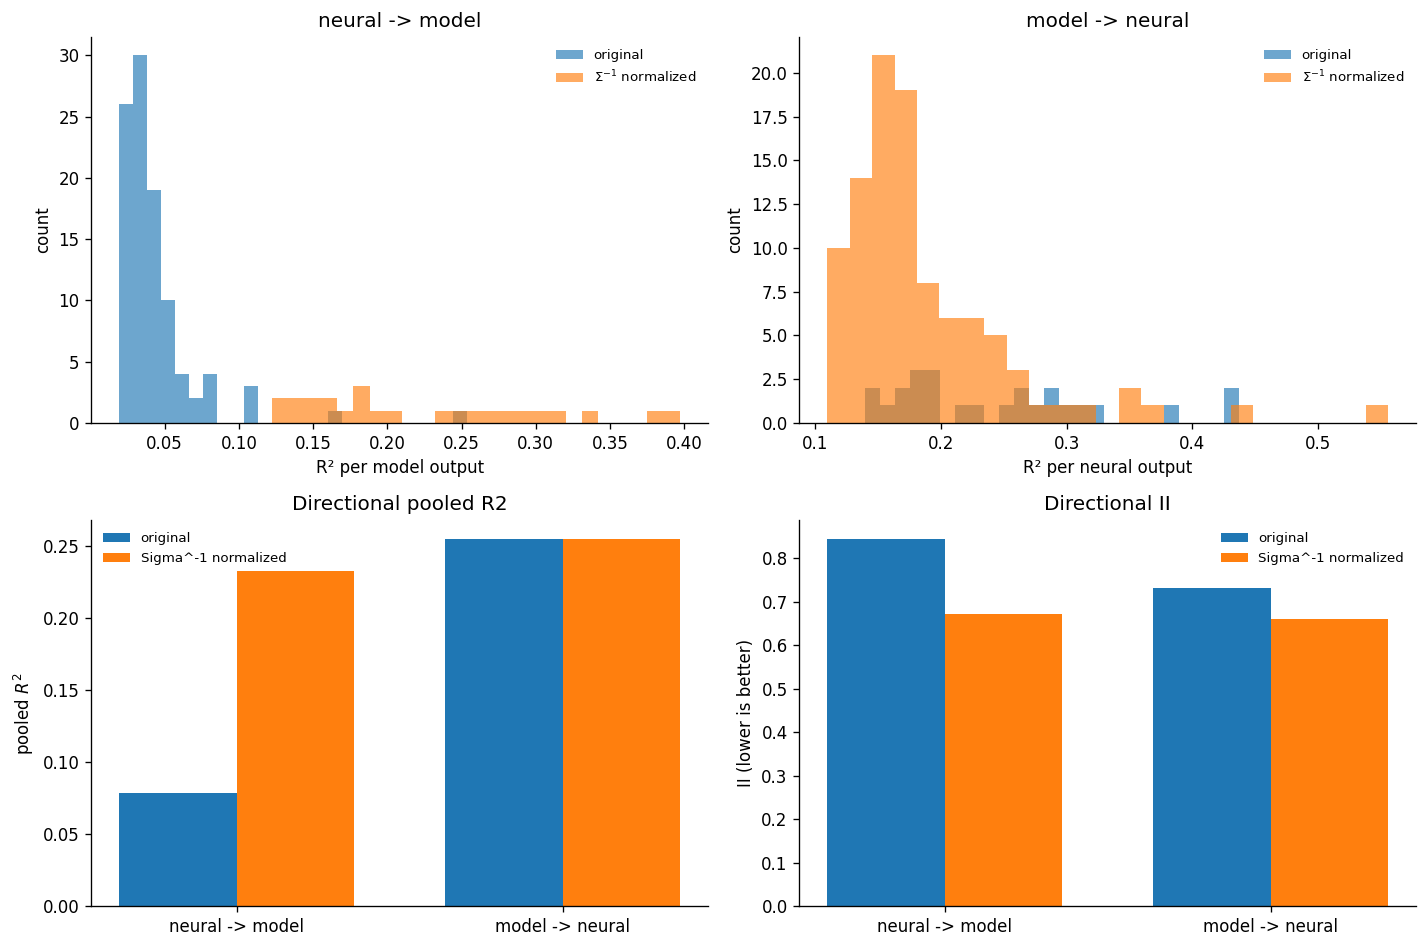

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
original_fit = pipeline["original_fit"]
transformed_fit = pipeline["transformed_fit"]

axes[0, 0].hist(
    original_fit["r2_source_to_target"], bins=25, alpha=0.65, label="original"
)
axes[0, 0].hist(
    transformed_fit["r2_source_to_target"], bins=25, alpha=0.65,
    label=r"$\Sigma^{-1}$ normalized",
)
axes[0, 0].set(title="neural -> model", xlabel="R² per model output", ylabel="count")

axes[0, 1].hist(
    original_fit["r2_target_to_source"], bins=25, alpha=0.65, label="original"
)
axes[0, 1].hist(
    transformed_fit["r2_target_to_source"], bins=25, alpha=0.65,
    label=r"$\Sigma^{-1}$ normalized",
)
axes[0, 1].set(title="model -> neural", xlabel="R² per neural output", ylabel="count")

for ax, metric, ylabel in (
    (axes[1, 0], "pooled R2", r"pooled $R^2$"),
    (axes[1, 1], "II", "II (lower is better)"),
):
    x_positions = np.arange(2)
    width = 0.36
    for offset, (stage, stage_rows) in zip(
        (-width / 2, width / 2), summary.groupby("stage", sort=False)
    ):
        ax.bar(x_positions + offset, stage_rows[metric], width, label=stage)
    # end for offset, (stage, stage_rows)
    ax.set_xticks(x_positions, ["neural -> model", "model -> neural"])
    ax.set(ylabel=ylabel, title=f"Directional {metric}")
# end for ax, metric, ylabel

for ax in axes.flat:
    ax.legend(frameon=False, fontsize=8)
# end for ax in axes.flat
fig.tight_layout()
plt.show()

## Variance hierarchy of shared linear directions

This section asks a different question from the coefficient-matrix SVD above:
**does shared linear information occupy the same position in the variance
hierarchy of the neural and model representations?** PCA is fitted separately
to the two centered spaces. Numerically zero-variance PCs are removed, while
each retained weight remains its explained-variance ratio relative to the
total variance of the representation supplied to this analysis.

For neural PC $i$ and model PC $j$, the non-negative in-sample coupling is
$C_{ij}=r^2(Z_{X,i},Z_{Y,j})$. Its signed variance-mismatch contribution is
$A_{ij}=C_{ij}(v_i^X-v_j^Y)$. We also report the normalized signed coefficient,
the unsigned mismatch $M_{\mathrm{var}}$, and the normalized-rank coefficient
$A_{\mathrm{rank}}$.

### Is the pairwise matrix an exact decomposition here?

The notebook's pooled score is $1-\sum_{ni}e_{ni}^2/\sum_{ni}(x_{ni}-\bar{x}_i)^2$.
An orthogonal change to a complete target-PC basis preserves both
sums, giving
$R^2_{Y\rightarrow X}=\sum_i v_i^X R^2(X_i\mid Y)$ and the reciprocal result.
Moreover, on the same data used to fit PCA and OLS, predictor PC columns are
centered and mutually orthogonal. Therefore the usual cross-terms vanish and
$R^2(X_i\mid Y)=\sum_j r^2(X_i,Y_j)$; one-to-one coupling is not required.
Under these specific in-sample, unregularized, complete-basis conventions,
$\Delta R^2=\sum_{ij}C_{ij}(v_i^X-v_j^Y)$ should be exact up to numerical
precision.

This second step is **not automatic in general**. Held-out predictor PCs are
not orthogonal on a test fold, cross-validated univariate $R^2$ can be negative,
and truncation or regularization changes the identity. For that reason the
code below always computes the exact multivariate target-PC decomposition
independently and reports both factorization residuals. The current notebook
has no train/test framework, so every displayed coupling matrix is explicitly
labeled **in-sample**.

### Sanity-check simulations

The four cases isolate matched ordering, a directional reversed ordering,
signed cancellation, and extra independent dimensions. The last case is a
reminder that adding dimensions can dilute the variance share of otherwise
unchanged shared axes; that ambient-rank mechanism should not be mistaken for
an intrinsic reordering of the shared subspace.

In [6]:
rng = np.random.default_rng(cfg.simulation_seed)
n_sim = cfg.simulation_n_samples

# Simulation 1: identical shared axes and variance order.
matched_latent = rng.normal(size=(n_sim, 3))
matched_X = matched_latent * np.sqrt([0.70, 0.20, 0.10])
matched_Y = matched_X.copy()

# Simulation 2: dominant X maps to peripheral Y and peripheral X maps to
# dominant Y. Unequal mismatches leave a nonzero signed contribution.
reversed_latent = rng.normal(size=(n_sim, 4))
reversed_X = np.column_stack(
    (
        np.sqrt(0.70) * reversed_latent[:, 0],
        np.sqrt(0.25) * reversed_latent[:, 2],
        np.sqrt(0.05) * reversed_latent[:, 1],
    )
)
reversed_Y = np.column_stack(
    (
        np.sqrt(0.50) * reversed_latent[:, 1],
        np.sqrt(0.45) * reversed_latent[:, 3],
        np.sqrt(0.05) * reversed_latent[:, 0],
    )
)

# Simulation 3: equally strong reversed couplings cancel in the signed sum.
cancellation_latent = rng.normal(size=(n_sim, 2))
cancellation_X = cancellation_latent * np.sqrt([0.80, 0.20])
cancellation_Y = np.column_stack(
    (
        np.sqrt(0.80) * cancellation_latent[:, 1],
        np.sqrt(0.20) * cancellation_latent[:, 0],
    )
)

# Simulation 4: preserve the shared coordinates and append Y-only dimensions.
dimension_latent = rng.normal(size=(n_sim, 2))
dimension_X = dimension_latent * np.sqrt([0.70, 0.30])
dimension_Y = np.column_stack(
    (dimension_X, 0.35 * rng.normal(size=(n_sim, 6)))
)

simulations = {
    "1 matched": (matched_X, matched_Y),
    "2 reversed": (reversed_X, reversed_Y),
    "3 cancellation": (cancellation_X, cancellation_Y),
    "4 dimensions only": (dimension_X, dimension_Y),
}
simulation_results = {}
simulation_rows = []

for simulation_name, (simulation_X, simulation_Y) in simulations.items():
    pc_sim = compute_pc_coupling_matrix(simulation_X, simulation_Y)
    asymmetry_sim = compute_variance_asymmetry(
        pc_sim["coupling"],
        pc_sim["variance_ratio_X"],
        pc_sim["variance_ratio_Y"],
    )
    exact_sim = decompose_pooled_r2_in_pc_basis(
        pc_sim["scores_X"],
        pc_sim["scores_Y"],
        pc_sim["variance_ratio_X"],
        pc_sim["variance_ratio_Y"],
    )
    simulation_results[simulation_name] = (pc_sim, asymmetry_sim, exact_sim)
    simulation_rows.append(
        {
            "simulation": simulation_name,
            "exact delta R2": exact_sim["delta_r2"],
            "A_var": asymmetry_sim["A_var"],
            "factorization residual": (
                asymmetry_sim["A_var"] - exact_sim["delta_r2"]
            ),
            "A_var_norm": asymmetry_sim["A_var_norm"],
            "M_var": asymmetry_sim["M_var"],
            "A_rank": asymmetry_sim["A_rank"],
        }
    )
# end for simulation_name, (simulation_X, simulation_Y)

simulation_summary = pd.DataFrame(simulation_rows).set_index("simulation")
display(simulation_summary.style.format("{:.6f}"))

,exact delta R2,A_var,factorization residual,A_var_norm,M_var,A_rank
simulation,,,,,,
1 matched,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2 reversed,0.194424,0.194424,0.000000,0.097209,0.553341,-0.000376
3 cancellation,-0.000000,0.000000,0.000000,0.000000,0.599732,0.000000
4 dimensions only,0.427361,0.427361,0.000000,0.213681,0.213681,-0.428390


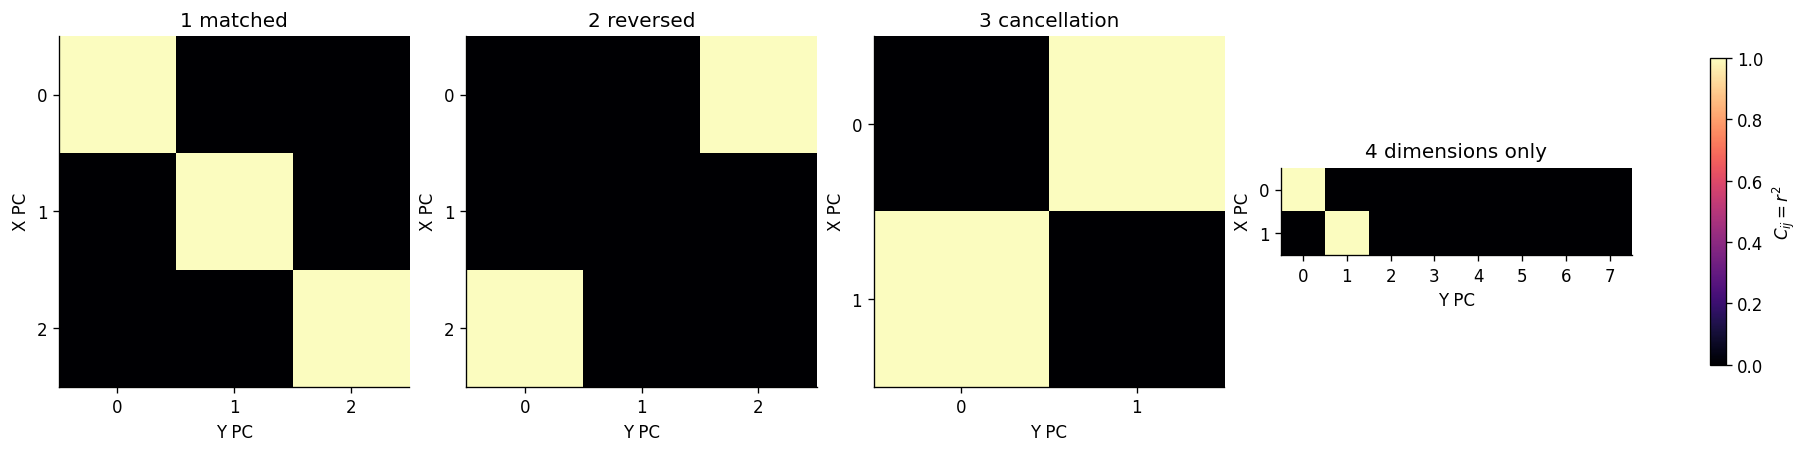

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), constrained_layout=True)
for axis, (simulation_name, (pc_sim, _, _)) in zip(
    axes, simulation_results.items()
):
    image = axis.imshow(pc_sim["coupling"], vmin=0, vmax=1, cmap="magma")
    axis.set(
        title=simulation_name,
        xlabel="Y PC",
        ylabel="X PC",
        xticks=np.arange(pc_sim["coupling"].shape[1]),
        yticks=np.arange(pc_sim["coupling"].shape[0]),
    )
# end for axis, (simulation_name, (pc_sim, _, _))
fig.colorbar(image, ax=axes, label=r"$C_{ij}=r^2$", shrink=0.8)
plt.show()

### Neural/model variance hierarchy after SVD null-space removal

The analysis below no longer uses the original ambient representations. Here
$X=\widetilde X$ and $Y=\widetilde Y$ are the two SVD-transformed spaces from
the preceding pipeline. For a fitted map $W=U\Sigma V^T$, the transform is
$VI_rU^T$: it retains only active right-singular directions, drops the null
directions that cannot participate in the fitted relation, and does not apply
the singular-value gains $\Sigma$. Because the remaining $U$ factor is an
orthogonal embedding, PCA on the transformed samples has the same spectrum as
PCA on their active $XV_r$ or $YV_r$ coordinates. Thus the variance ratios are
renormalized within the linearly relevant subspaces rather than being diluted
by discarded ambient dimensions.

Positive signed values therefore favor model-to-neural pooled predictivity:
the coupled direction carries a larger fraction of neural variance than model
variance. The componentwise multivariate OLS calculation is the exact reference;
the pairwise matrix is both verified against it and retained as the map showing
where shared information lies in the two spectra.

In [8]:
# Use the SVD-filtered spaces, not the original ambient representations.
neural_svd_samples = pipeline["transformed_source"]
model_svd_samples = pipeline["transformed_target"]
svd_fit = pipeline["transformed_fit"]
pc_variance = compute_pc_coupling_matrix(
    neural_svd_samples, model_svd_samples
)
variance_asymmetry = compute_variance_asymmetry(
    pc_variance["coupling"],
    pc_variance["variance_ratio_X"],
    pc_variance["variance_ratio_Y"],
)
exact_pc_decomposition = decompose_pooled_r2_in_pc_basis(
    pc_variance["scores_X"],
    pc_variance["scores_Y"],
    pc_variance["variance_ratio_X"],
    pc_variance["variance_ratio_Y"],
)

R2_X_to_Y = svd_fit["pooled_r2_source_to_target"]
R2_Y_to_X = svd_fit["pooled_r2_target_to_source"]
observed_delta_R2 = R2_Y_to_X - R2_X_to_Y
coupling = pc_variance["coupling"]

# In-sample orthogonal predictors imply these row/column sums should match the
# independently fitted multivariate target-PC R2 values.
pairwise_component_X = coupling.sum(axis=1)
pairwise_component_Y = coupling.sum(axis=0)
max_component_residual = max(
    np.max(
        np.abs(
            pairwise_component_X
            - exact_pc_decomposition["component_r2_X_from_Y"]
        )
    ),
    np.max(
        np.abs(
            pairwise_component_Y
            - exact_pc_decomposition["component_r2_Y_from_X"]
        )
    ),
)
pooled_pc_residual = exact_pc_decomposition["delta_r2"] - observed_delta_R2
pairwise_factorization_residual = variance_asymmetry["A_var"] - observed_delta_R2

variance_summary = pd.Series(
    {
        "R2 neural SVD -> model SVD": R2_X_to_Y,
        "R2 model SVD -> neural SVD": R2_Y_to_X,
        "observed delta R2": observed_delta_R2,
        "exact PC-weighted R2 neural -> model": (
            exact_pc_decomposition["pooled_r2_X_to_Y"]
        ),
        "exact PC-weighted R2 model -> neural": (
            exact_pc_decomposition["pooled_r2_Y_to_X"]
        ),
        "exact PC-weighted delta R2": exact_pc_decomposition["delta_r2"],
        "exact-PC minus observed residual": pooled_pc_residual,
        "A_var (pairwise delta)": variance_asymmetry["A_var"],
        "pairwise minus observed residual": pairwise_factorization_residual,
        "A_var_norm": variance_asymmetry["A_var_norm"],
        "M_var": variance_asymmetry["M_var"],
        "A_rank": variance_asymmetry["A_rank"],
        "max target-PC factorization residual": max_component_residual,
    },
    name="value",
)
display(variance_summary.to_frame().style.format("{:.10f}"))

factorization_verified = (
    abs(pooled_pc_residual) <= cfg.verification_atol
    and abs(pairwise_factorization_residual) <= cfg.verification_atol
    and max_component_residual <= cfg.verification_atol
)
print(
    "Exact in-sample PCA factorization verified: "
    f"{factorization_verified} (atol={cfg.verification_atol:g})"
)

,value
R2 neural SVD -> model SVD,0.2326691247
R2 model SVD -> neural SVD,0.2551865023
observed delta R2,0.0225173777
exact PC-weighted R2 neural -> model,0.2326691247
exact PC-weighted R2 model -> neural,0.2551865023
exact PC-weighted delta R2,0.0225173777
exact-PC minus observed residual,0.0000000000
A_var (pairwise delta),0.0225173777
pairwise minus observed residual,0.0000000000
A_var_norm,0.0051140849


Exact in-sample PCA factorization verified: True (atol=1e-08)


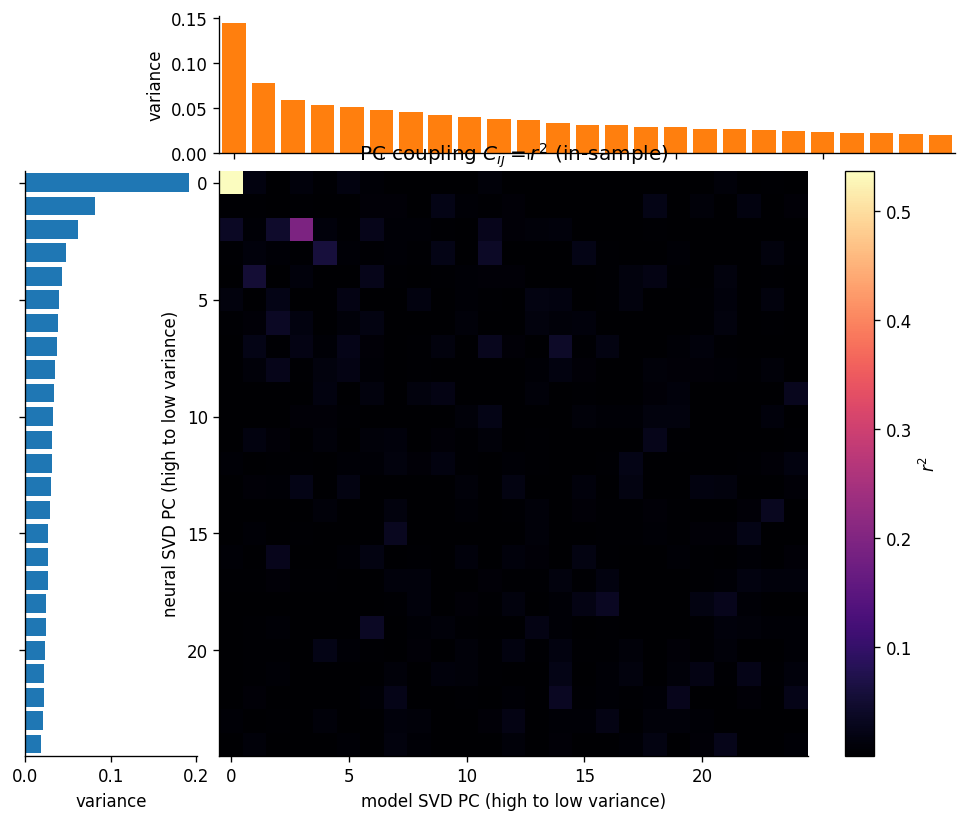

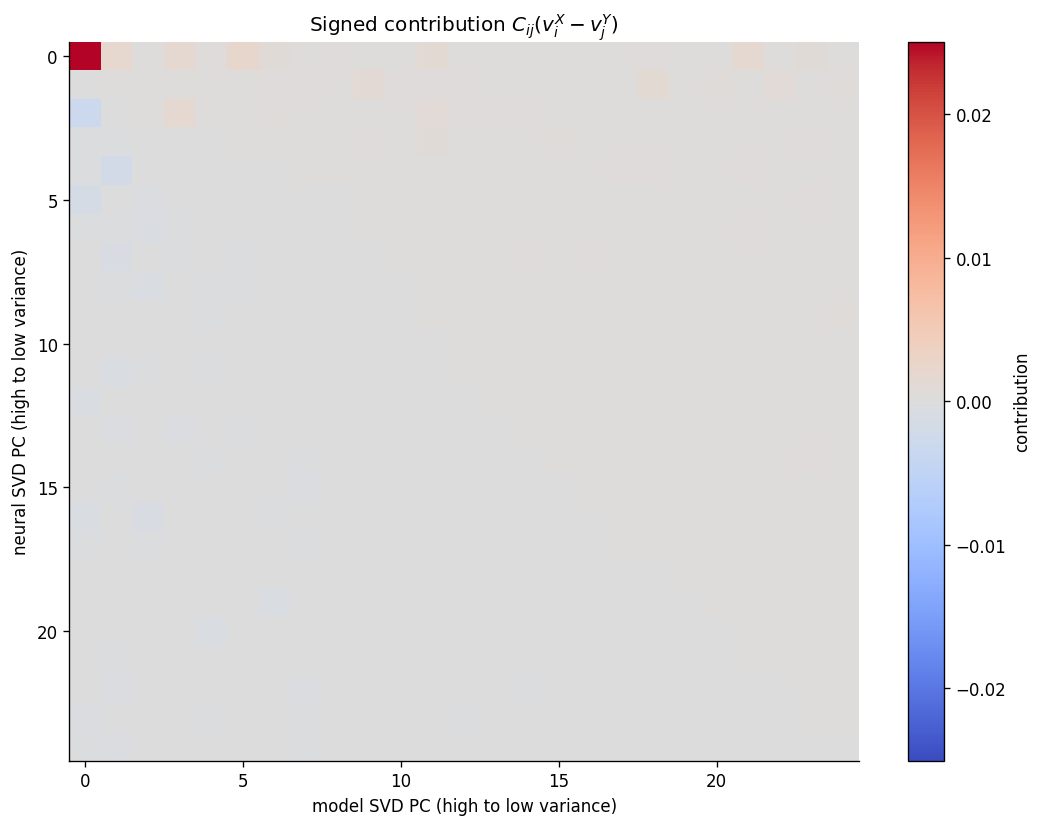

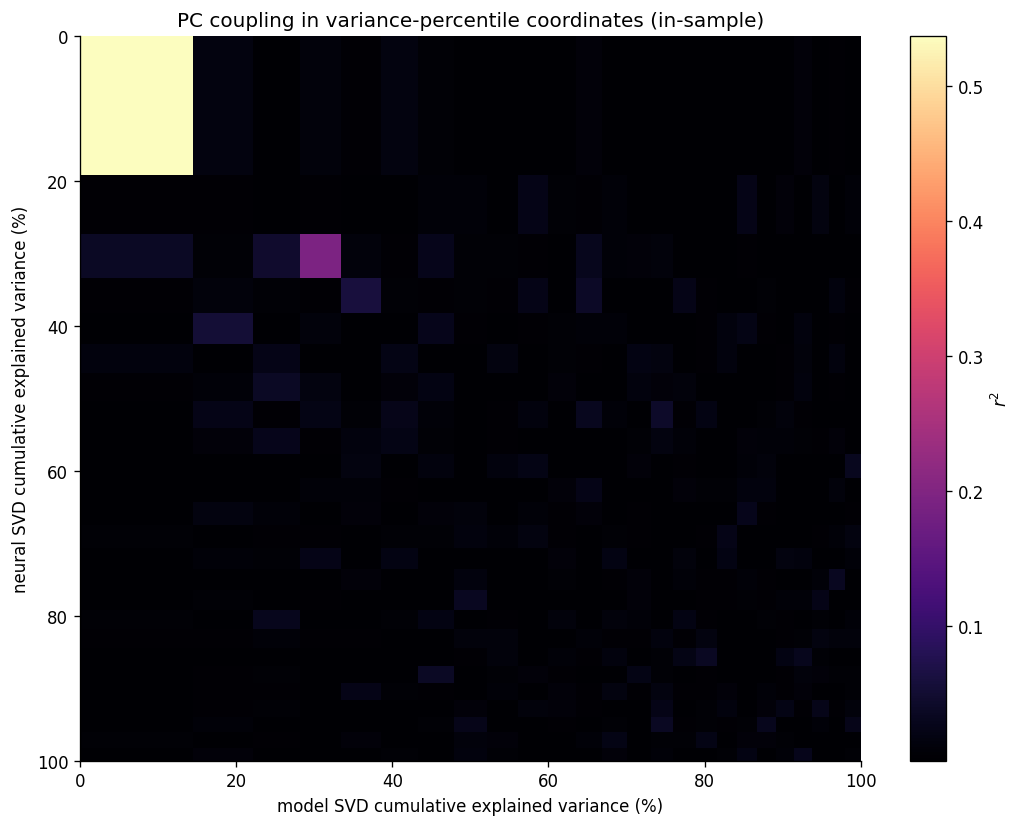

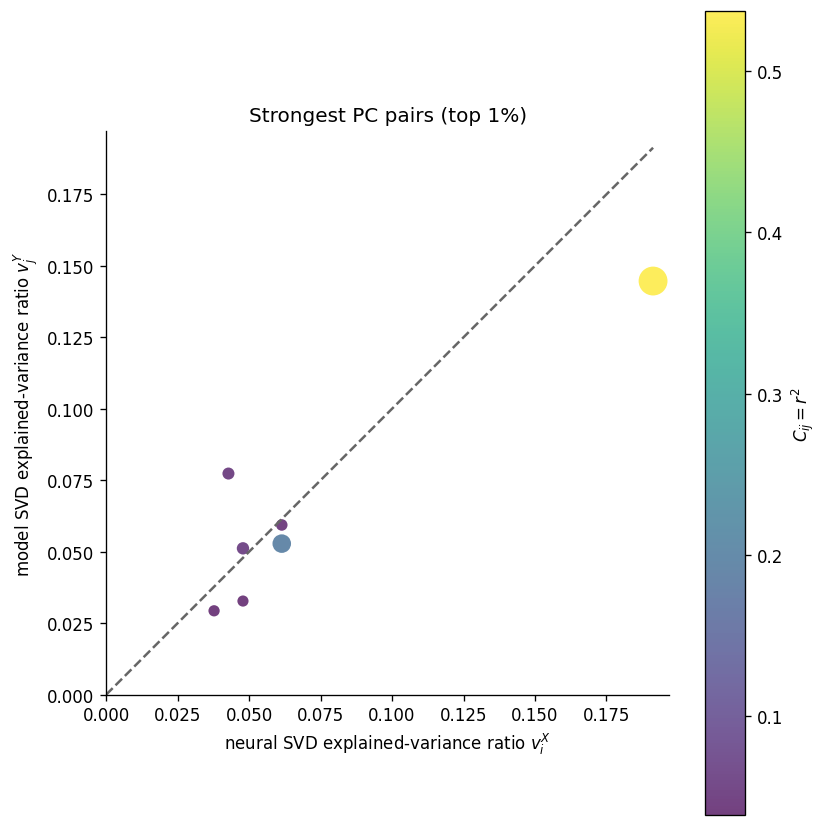

In [9]:
variance_figures = plot_pc_coupling(
    pc_variance,
    variance_asymmetry,
    X_name="neural SVD",
    Y_name="model SVD",
    coupling_quantile=cfg.coupling_quantile,
)
plt.show()

### Original model versus model-only SVD projection: II and RSA

This comparison keeps the neural samples unchanged. The second model condition
is pipeline["transformed_target"], obtained from the model-to-neural OLS map
$W=U\Sigma V^T$ using $VI_rU^T$. It therefore removes model directions in the
null space and omits the singular-value stretching $\Sigma$. Both conditions
use exactly the configured neural and model RDM metrics. II is directional and
lower is better; RSA is symmetric and higher is better.

Because the SVD projection was fitted on these same matched samples, this is a
descriptive in-sample comparison rather than an unbiased estimate of improvement
on new stimuli.

,II neural -> model,II model -> neural,RSA (correlation)
model space,,,
original model,0.844614,0.731979,0.151033
model SVD (no Sigma),0.670625,0.661192,0.304381


,SVD minus original
II neural -> model,-0.173989
II model -> neural,-0.070787
RSA (correlation),+0.153348


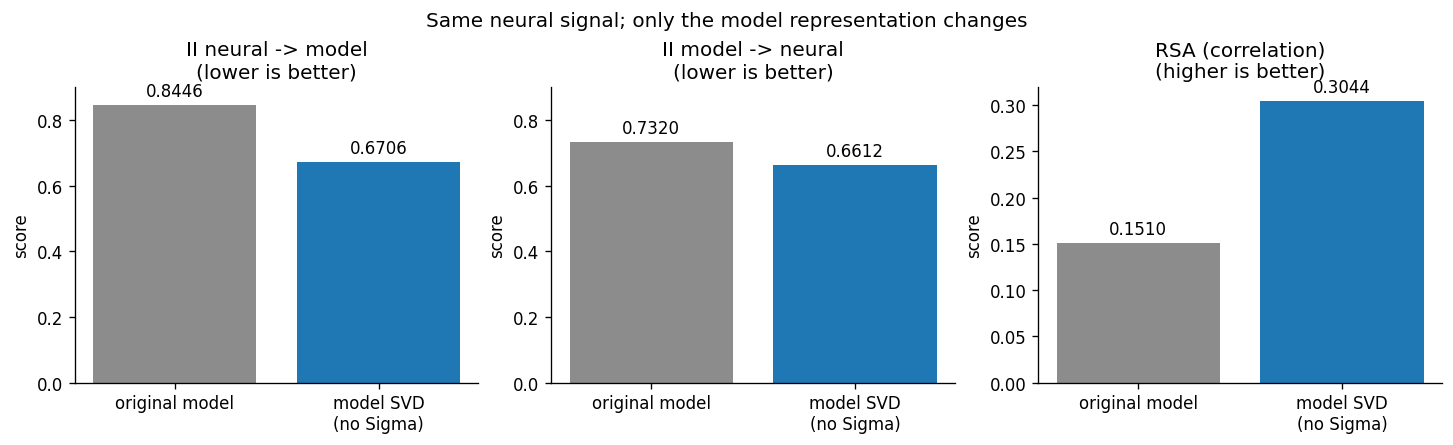

In [13]:
model_spaces_for_comparison = {
    "original model": model_samples,
    "model SVD (no Sigma)": pipeline["transformed_target"],
}
ii_rsa_rows = []

for model_space_name, compared_model_samples in model_spaces_for_comparison.items():
    ii_result = compute_bidirectional_ii(
        neural_samples,
        compared_model_samples,
        source_metric=cfg.neural_RDM_metric,
        target_metric=cfg.model_RDM_metric,
        k=cfg.k,
    )

    # RSA and II receive features in rows through their established utilities.
    rsa = RSA(
        cfg.neural_RDM_metric,
        cfg.model_RDM_metric,
        RSA_metric=cfg.RSA_metric,
    )
    rsa.compute_both_RDMs(neural_samples.T, compared_model_samples.T)
    rsa_similarity = float(rsa.compute_RSA())

    ii_rsa_rows.append(
        {
            "model space": model_space_name,
            "II neural -> model": ii_result["source_to_target"],
            "II model -> neural": ii_result["target_to_source"],
            f"RSA ({cfg.RSA_metric})": rsa_similarity,
        }
    )
# end for model_space_name, compared_model_samples

ii_rsa_comparison = pd.DataFrame(ii_rsa_rows).set_index("model space")
ii_rsa_change = (
    ii_rsa_comparison.loc["model SVD (no Sigma)"]
    - ii_rsa_comparison.loc["original model"]
)
display(ii_rsa_comparison.style.format("{:.6f}"))
display(ii_rsa_change.rename("SVD minus original").to_frame().style.format("{:+.6f}"))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
comparison_labels = ["original model", "model SVD\n(no Sigma)"]
for axis, metric_name in zip(axes, ii_rsa_comparison.columns):
    metric_values = ii_rsa_comparison[metric_name].to_numpy()
    bars = axis.bar(comparison_labels, metric_values, color=["0.55", "tab:blue"])
    direction = "lower is better" if metric_name.startswith("II") else "higher is better"
    if "II" in metric_name:
        axis.set(title=f"{metric_name}\n({direction})", ylabel="score", ylim=[0,.9]) 
    else:
        axis.set(title=f"{metric_name}\n({direction})", ylabel="score") 
    axis.bar_label(bars, fmt="%.4f", padding=3)
    # axis.margins(y=0.15)
# end for axis, metric_name
fig.suptitle("Same neural signal; only the model representation changes")
plt.show()

## Interpretation caveat

These are descriptive in-sample OLS values, matching the Gaussian source
notebook. High-dimensional representations can interpolate targets, so these
pooled R² values should not be read as held-out generalization performance.
II is computed directly from each representation before and after the fitted
transforms; it is not computed from regression predictions.